In [1]:
import numpy as np
import pandas  as pd

In [2]:
df = pd.read_csv(r"E:\Innomatics\Flight Delay Analysis\Flight_Delays_50K.csv")


**Dataset Understanding And Exploration**

In [3]:
df.shape

(50000, 31)

In [4]:
#Datatype of each column
df.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 50000 non-null  int64  
 1   MONTH                50000 non-null  int64  
 2   DAY                  50000 non-null  int64  
 3   DAY_OF_WEEK          50000 non-null  int64  
 4   AIRLINE              50000 non-null  object 
 5   FLIGHT_NUMBER        50000 non-null  int64  
 6   TAIL_NUMBER          49871 non-null  object 
 7   ORIGIN_AIRPORT       50000 non-null  object 
 8   DESTINATION_AIRPORT  50000 non-null  object 
 9   SCHEDULED_DEPARTURE  50000 non-null  int64  
 10  DEPARTURE_TIME       49234 non-null  float64
 11  DEPARTURE_DELAY      49234 non-null  float64
 12  TAXI_OUT             49215 non-null  float64
 13  WHEELS_OFF           49215 non-null  float64
 14  SCHEDULED_TIME       50000 non-null  float64
 15  ELAPSED_TIME         49085 non-null 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,50000.0,2015.000000,0.000000,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,50000.0,6.543440,3.395736,1.0,4.0,7.0,9.0,12.0
DAY,50000.0,15.686100,8.777680,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,50000.0,3.941880,1.992019,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,50000.0,2177.016720,1759.888911,1.0,733.0,1686.0,3246.0,8410.0
SCHEDULED_DEPARTURE,50000.0,1326.620920,483.235737,3.0,915.0,1324.0,1730.0,2359.0
DEPARTURE_TIME,49234.0,1330.928728,496.210684,1.0,919.0,1327.0,1737.0,2400.0
DEPARTURE_DELAY,49234.0,9.086526,35.464728,-55.0,-5.0,-2.0,7.0,1515.0
TAXI_OUT,49215.0,16.019344,8.805555,1.0,11.0,14.0,19.0,149.0
WHEELS_OFF,49215.0,1352.902387,497.512045,1.0,933.0,1340.0,1751.0,2400.0


In [7]:
#Total number rows
rows = df.shape[0]
rows

50000

In [8]:
#Total number of columns
columns = df.shape[1]
columns

31

In [9]:
#Features available in the dataset
df.columns.tolist()

['YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'AIRLINE',
 'FLIGHT_NUMBER',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'CANCELLATION_REASON',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

In [10]:
#Numerical Columns
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
numerical_cols

['YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'FLIGHT_NUMBER',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

In [11]:
#Categorical Columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols

['AIRLINE',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'CANCELLATION_REASON']

**Data Cleaning**

In [12]:
df.columns = df.columns.str.lower()

In [13]:
df = df.rename(columns={
    'wheels_off': 'takeoff_time',
    'wheels_on': 'landing_time'
})

In [14]:
#findng null values
df.isna().sum().sort_values(ascending=False)

cancellation_reason    49206
late_aircraft_delay    40900
weather_delay          40900
airline_delay          40900
air_system_delay       40900
security_delay         40900
elapsed_time             915
air_time                 915
arrival_delay            915
landing_time             818
taxi_in                  818
arrival_time             818
takeoff_time             785
taxi_out                 785
departure_time           766
departure_delay          766
tail_number              129
scheduled_time             0
origin_airport             0
day                        0
day_of_week                0
airline                    0
flight_number              0
year                       0
month                      0
destination_airport        0
scheduled_departure        0
scheduled_arrival          0
distance                   0
diverted                   0
cancelled                  0
dtype: int64

In [15]:
null_percentage = df.isnull().sum()/len(df)*100
null_percentage = null_percentage.sort_values(ascending=False)
print(null_percentage)


cancellation_reason    98.412
late_aircraft_delay    81.800
weather_delay          81.800
airline_delay          81.800
air_system_delay       81.800
security_delay         81.800
elapsed_time            1.830
air_time                1.830
arrival_delay           1.830
landing_time            1.636
taxi_in                 1.636
arrival_time            1.636
takeoff_time            1.570
taxi_out                1.570
departure_time          1.532
departure_delay         1.532
tail_number             0.258
scheduled_time          0.000
origin_airport          0.000
day                     0.000
day_of_week             0.000
airline                 0.000
flight_number           0.000
year                    0.000
month                   0.000
destination_airport     0.000
scheduled_departure     0.000
scheduled_arrival       0.000
distance                0.000
diverted                0.000
cancelled               0.000
dtype: float64


In [16]:
#checking for duplicate values
print(df.duplicated().sum())

0


In [17]:
#creating a new column called DATE_OF_JOURNEY
date_of_journey = pd.to_datetime({
    "year" : df["year"],
    "month" : df["month"],
    "day" : df["day"]
})


In [18]:
#Inserting the new location at a specific location
df.insert(loc=0, column="date_of_journey", value = date_of_journey)

In [19]:
#dropping the  columns "year", "month", "day" 
df.drop(["year","day"], axis = 1, inplace = True)

In [20]:
#changing the datatype of the month column to category
df["month"] = df["date_of_journey"].dt.month_name().astype("category")


df["day_of_week"] = df["date_of_journey"].dt.day_name().astype("category")

In [21]:
#imputing the missing values in the column "tail_number" with "Anonymous"
df["tail_number"] = df["tail_number"].fillna("Anonymous")

In [22]:
time_cols = [
    "scheduled_departure",
    "departure_time",
    "takeoff_time",
    "landing_time",
    "scheduled_arrival",
    "arrival_time"
]

for col in time_cols:
    df[col] = pd.to_datetime(
        df[col].astype("Int64").astype(str).str.zfill(4),
        format="%H%M",
        errors="coerce"
    ).dt.time

In [23]:
#checking for negative values in the column "distance"
df[df["distance"] <= 0]

,date_of_journey,month,day_of_week,airline,flight_number,tail_number,origin_airport,destination_airport,scheduled_departure,departure_time,...,arrival_time,arrival_delay,diverted,cancelled,cancellation_reason,air_system_delay,security_delay,airline_delay,late_aircraft_delay,weather_delay


In [24]:
#checking for negative values in the column "air_time"
df[df["air_time"] <= 0]

,date_of_journey,month,day_of_week,airline,flight_number,tail_number,origin_airport,destination_airport,scheduled_departure,departure_time,...,arrival_time,arrival_delay,diverted,cancelled,cancellation_reason,air_system_delay,security_delay,airline_delay,late_aircraft_delay,weather_delay


In [25]:
#Handling the missing avlues in the values in the columns:
# "air_system_delay","security_delay","airline_delay","late_aircraft_delay","weather_delay"

delay_cols = [
    "air_system_delay",
    "security_delay",
    "airline_delay",
    "late_aircraft_delay",
    "weather_delay"
]

df[delay_cols] = df[delay_cols].fillna(0)


In [26]:
#Handling missing values in the column "CANCELLATION_REASON"
df["cancellation_reason"] = df["cancellation_reason"].fillna("Not Cancelled")

In [27]:
df.isnull().sum().sort_values(ascending=False)

air_time               915
elapsed_time           915
arrival_delay          915
landing_time           842
arrival_time           834
taxi_in                818
takeoff_time           787
taxi_out               785
departure_time         768
departure_delay        766
tail_number              0
flight_number            0
date_of_journey          0
month                    0
scheduled_time           0
origin_airport           0
destination_airport      0
scheduled_departure      0
day_of_week              0
airline                  0
distance                 0
scheduled_arrival        0
diverted                 0
cancelled                0
cancellation_reason      0
air_system_delay         0
security_delay           0
airline_delay            0
late_aircraft_delay      0
weather_delay            0
dtype: int64

Outlier Analysis

In [28]:
Q1 = df["arrival_delay"].quantile(0.25)

Q3 = df["arrival_delay"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["arrival_delay"] < lower) |
    (df["arrival_delay"] > upper)
]


In [29]:
outliers

,date_of_journey,month,day_of_week,airline,flight_number,tail_number,origin_airport,destination_airport,scheduled_departure,departure_time,...,arrival_time,arrival_delay,diverted,cancelled,cancellation_reason,air_system_delay,security_delay,airline_delay,late_aircraft_delay,weather_delay
43,2015-01-16,January,Friday,AS,302,N708AS,SEA,SFO,17:55:00,19:16:00,...,21:13:00,75.0,0,0,Not Cancelled,75.0,0.0,0.0,0.0,0.0
51,2015-11-22,November,Sunday,UA,1530,N69847,EWR,CLE,15:54:00,16:44:00,...,18:10:00,41.0,0,0,Not Cancelled,0.0,0.0,0.0,41.0,0.0
58,2015-03-23,March,Monday,EV,6138,N12552,ORD,OKC,09:10:00,15:32:00,...,17:57:00,386.0,0,0,Not Cancelled,4.0,0.0,4.0,6.0,372.0
59,2015-01-12,January,Monday,MQ,3450,N925MQ,MAF,DFW,14:35:00,16:05:00,...,17:37:00,112.0,0,0,Not Cancelled,22.0,0.0,46.0,44.0,0.0
80,2015-03-20,March,Friday,US,729,N664AW,PHL,SEA,18:00:00,18:00:00,...,22:33:00,80.0,0,0,Not Cancelled,80.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49944,2015-06-28,June,Sunday,B6,108,N231JB,JFK,PWM,22:45:00,00:07:00,...,01:17:00,71.0,0,0,Not Cancelled,0.0,0.0,1.0,70.0,0.0
49953,2015-02-02,February,Monday,DL,2052,N363NW,ATL,CLT,19:30:00,20:24:00,...,21:26:00,43.0,0,0,Not Cancelled,0.0,0.0,11.0,32.0,0.0
49969,2015-02-23,February,Monday,OO,6352,N712SK,BOI,SFO,17:48:00,19:30:00,...,19:54:00,79.0,0,0,Not Cancelled,0.0,0.0,0.0,79.0,0.0
49981,2015-02-02,February,Monday,B6,1285,N197JB,BOS,PIT,06:15:00,06:13:00,...,08:56:00,44.0,0,0,Not Cancelled,44.0,0.0,0.0,0.0,0.0


In [30]:
outliers_count = outliers.shape[0]
outliers_count

4317

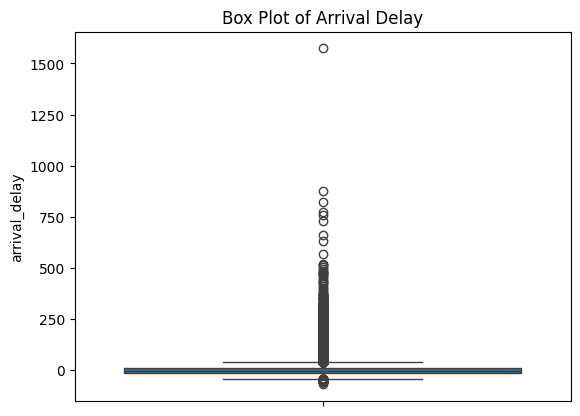

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(df["arrival_delay"].dropna())
plt.title("Box Plot of Arrival Delay")
plt.show()

In [45]:
import plotly.express as px
fig = px.box(df["arrival_delay"], title="Box Plot of Arrival Delay", labels={"value": "Arrival Delay (minutes)"})
fig.show()

In [33]:
Q1 = df["distance"].quantile(0.25)

Q3 = df["distance"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers_dist = df[
    (df["distance"] < lower) |
    (df["distance"] > upper)
]

In [34]:
outliers_dist

,date_of_journey,month,day_of_week,airline,flight_number,tail_number,origin_airport,destination_airport,scheduled_departure,departure_time,...,arrival_time,arrival_delay,diverted,cancelled,cancellation_reason,air_system_delay,security_delay,airline_delay,late_aircraft_delay,weather_delay
0,2015-05-14,May,Thursday,US,1721,N174US,CLT,SMF,18:10:00,18:30:00,...,20:43:00,4.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
3,2015-12-21,December,Monday,UA,1929,N460UA,SEA,EWR,06:22:00,06:23:00,...,14:14:00,-17.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
8,2015-12-11,December,Friday,AS,745,N433AS,ATL,SEA,18:40:00,18:48:00,...,21:20:00,1.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
27,2015-04-10,April,Friday,AA,10,N790AA,LAX,JFK,21:55:00,21:47:00,...,05:58:00,-25.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
63,2015-11-02,November,Monday,UA,1562,N13227,ANC,ORD,20:00:00,19:54:00,...,04:42:00,-22.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49919,2015-12-14,December,Monday,UA,1460,N69826,EWR,LAS,20:50:00,20:56:00,...,23:24:00,-16.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
49942,2015-07-21,July,Tuesday,AS,899,N596AS,PDX,OGG,08:40:00,08:59:00,...,11:46:00,16.0,0,0,Not Cancelled,0.0,0.0,0.0,16.0,0.0
49946,2015-04-21,April,Tuesday,UA,446,N465UA,LAX,EWR,07:30:00,07:26:00,...,15:44:00,-19.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
49950,2015-07-12,July,Sunday,AA,1800,N548UW,SEA,PHL,08:20:00,08:12:00,...,16:28:00,-2.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0


In [35]:
outliers_count = outliers_dist.shape[0]
outliers_count

3020

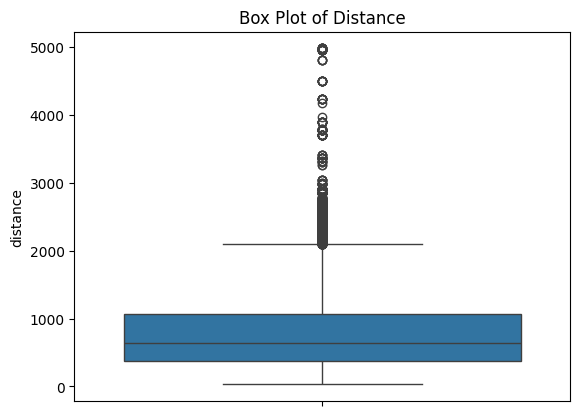

In [36]:
sns.boxplot(df["distance"])
plt.title("Box Plot of Distance")
plt.show()

In [37]:
Q1 = df["departure_delay"].quantile(0.25)

Q3 = df["departure_delay"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers_dep_delay = df[
    (df["departure_delay"] < lower) |
    (df["departure_delay"] > upper)
]

In [38]:
outliers_count = outliers_dep_delay.shape[0]
outliers_count

6261

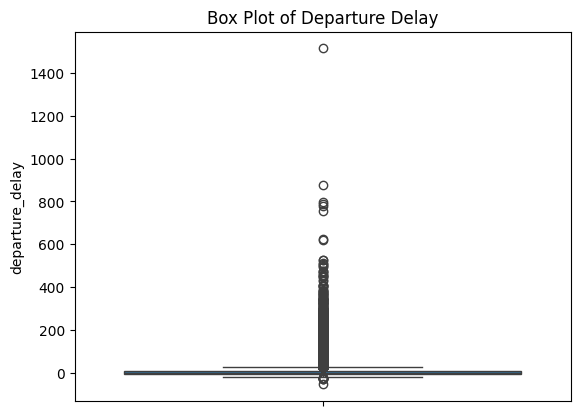

In [39]:
sns.boxplot(df["departure_delay"])
plt.title("Box Plot of Departure Delay")
plt.show()

In [40]:
Q1 = df["taxi_out"].quantile(0.25)

Q3 = df["taxi_out"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers_taxi_out = df[
    (df["taxi_out"] < lower) |
    (df["taxi_out"] > upper)
]

In [41]:
outliers_count = outliers_taxi_out.shape[0]
outliers_count

2370

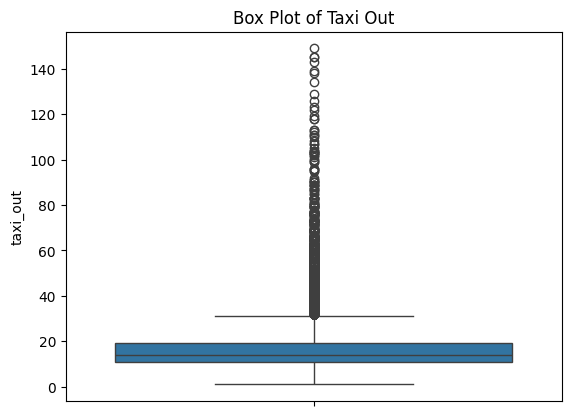

In [42]:
sns.boxplot(df["taxi_out"])
plt.title("Box Plot of Taxi Out")
plt.show()

In [56]:
df.to_csv("Flight_Delays_Cleaned_v2.csv", index=False)

In [57]:
import os


print(os.getcwd())

e:\Innomatics\Flight Delay Analysis
